# Combined Training and Inference Notebook

## Training Section
Code from train.py split into smaller cells

### 📦 Manual Model Upload Instructions

**If you already have trained models locally**, follow these steps:

1. **Open Google Drive** in your browser
2. **Navigate to** `My Drive`
3. **Create a folder** named `Medical_Classification_Models`
4. **Upload your `.pth` files** from your local `Saved/` folder to this Drive folder

**Expected models to upload:**
- `best_convnext_tiny_fold0.pth`
- `best_convnext_tiny_fold1.pth`
- `best_convnext_tiny_fold2.pth`
- `best_convnext_tiny_fold3.pth`
- `best_efficientnet_b3_fold0.pth`
- `best_efficientnet_b3_fold1.pth`
- `best_efficientnet_b3_fold2.pth`
- `best_efficientnet_b3_fold3.pth`

**Final path:** `/content/drive/MyDrive/Medical_Classification_Models/`

**Note:** You can skip the training section below if you've already uploaded your models!

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import timm
from PIL import Image
import json
import os
from pathlib import Path
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set random seeds for reproducibility
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Configuration
class Config:
    # Paths
    gdrive_data_path = '/content/drive/MyDrive'
    train_data_path = f'{gdrive_data_path}/output/train/data.json'
    train_img_dir = f'{gdrive_data_path}/output/train/imgs'
    test_data_path = f'{gdrive_data_path}/output/test/data.json'
    test_img_dir = f'{gdrive_data_path}/output/test/imgs'
    
    # Model storage path in Google Drive
    models_dir = f'{gdrive_data_path}/Medical_Classification_Models'

    # Model settings
    model_names = ['convnext_tiny', 'efficientnet_b3']
    img_size = 384
    num_classes = 7

    # Training settings
    batch_size = 16
    num_epochs = 40
    learning_rate = 1e-4
    weight_decay = 1e-5
    num_folds = 4

    # Device
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # Class names
    class_names = ['ear-left', 'ear-right', 'nose-left', 'nose-right', 'throat', 'vc-closed', 'vc-open']
    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

config = Config()
print(f'Using device: {config.device}')
print(f'Models will be saved to: {config.models_dir}')

Using device: cpu


In [ ]:
# Create models directory if it doesn't exist
import os
os.makedirs(config.models_dir, exist_ok=True)
print(f'✓ Models directory created/verified: {config.models_dir}')

In [ ]:
# Check for existing models in Google Drive
print('\n' + '='*60)
print('CHECKING FOR EXISTING MODELS IN GOOGLE DRIVE')
print('='*60)

existing_models = {}
missing_models = []

for model_name in config.model_names:
    existing_models[model_name] = []
    for fold in range(config.num_folds):
        model_path = os.path.join(config.models_dir, f'best_{model_name}_fold{fold}.pth')
        if os.path.exists(model_path):
            size_mb = os.path.getsize(model_path) / (1024 * 1024)
            existing_models[model_name].append(fold)
            print(f'✓ Found: {os.path.basename(model_path)} ({size_mb:.2f} MB)')
        else:
            missing_models.append(f'{model_name}_fold{fold}')
            print(f'✗ Missing: best_{model_name}_fold{fold}.pth')

total_expected = len(config.model_names) * config.num_folds
total_found = sum(len(folds) for folds in existing_models.values())

print(f'\n📊 Summary: {total_found}/{total_expected} models found in Google Drive')

if total_found == total_expected:
    print('\n✅ ALL MODELS FOUND! You can skip the training cells and go directly to inference.')
    SKIP_TRAINING = True
elif total_found > 0:
    print(f'\n⚠️  {len(missing_models)} models missing. Training will only train the missing models:')
    for missing in missing_models:
        print(f'   - {missing}')
    SKIP_TRAINING = False
else:
    print('\n⚠️  No models found. Training will train all models from scratch.')
    SKIP_TRAINING = False

print('='*60)

In [17]:
# Advanced augmentation for training with medical-specific improvements
def get_train_transforms():
    """Anatomy-aware augmentation - NO FLIPS to preserve left/right anatomical labels"""
    return A.Compose([
        A.Resize(config.img_size, config.img_size),
        # REMOVED: A.HorizontalFlip(p=0.5),  # Would swap left/right labels incorrectly!
        # REMOVED: A.VerticalFlip(p=0.3),  # Not anatomically correct for medical images
        A.Rotate(limit=15, p=0.4),  # Small rotation only - anatomical orientation matters

        # Medical imaging specific augmentations
        A.RandomGamma(gamma_limit=(80, 120), p=0.4),  # Different imaging devices
        A.Sharpen(alpha=(0.2, 0.5), lightness=(0.5, 1.0), p=0.3),  # Enhance anatomical details
        A.Equalize(p=0.2),  # Enhance contrast for subtle features

        A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.4),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.3),

        A.GaussNoise(var_limit=(5.0, 30.0), p=0.3),
        A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.5), p=0.2),  # Camera sensor noise

        A.OneOf([
            A.GaussianBlur(blur_limit=(3, 5), p=1.0),
            A.MotionBlur(blur_limit=5, p=1.0),
        ], p=0.3),

        A.CLAHE(clip_limit=4.0, p=0.4),
        A.ShiftScaleRotate(shift_limit=0.08, scale_limit=0.15, rotate_limit=15, p=0.4),
        A.CoarseDropout(max_holes=4, max_height=24, max_width=24, p=0.2),

        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ])

def get_val_transforms():
    return A.Compose([
        A.Resize(config.img_size, config.img_size),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2()
    ])

In [18]:
# Dataset class
class MedicalImageDataset(Dataset):
    def __init__(self, data_list, img_dir, transform=None):
        self.data_list = data_list
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        item = self.data_list[idx]
        img_path = os.path.join(self.img_dir, item['path'])

        # Load image
        image = Image.open(img_path).convert('RGB')
        image = np.array(image)

        # Apply transforms
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        label = config.class_to_idx[item['anatomical_region']]

        return image, label

In [19]:
# Model with multiple architectures
class EnsembleModel(nn.Module):
    def __init__(self, model_name, num_classes, pretrained=True):
        super().__init__()
        self.model = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=num_classes
        )

    def forward(self, x):
        return self.model(x)

In [20]:
# Label smoothing loss
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, pred, target):
        confidence = 1.0 - self.smoothing
        log_probs = torch.nn.functional.log_softmax(pred, dim=-1)
        nll_loss = -log_probs.gather(dim=-1, index=target.unsqueeze(1))
        nll_loss = nll_loss.squeeze(1)
        smooth_loss = -log_probs.mean(dim=-1)
        loss = confidence * nll_loss + self.smoothing * smooth_loss
        return loss.mean()

In [21]:
# Training function
def train_epoch(model, dataloader, criterion, optimizer, scheduler, device, scaler):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(dataloader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        # Mixed precision training
        with torch.amp.autocast("cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        running_loss += loss.item()

        pbar.set_postfix({'loss': running_loss/len(pbar), 'acc': 100.*correct/total})

    if scheduler is not None:
        scheduler.step()

    return running_loss / len(dataloader), 100. * correct / total

In [22]:
# Validation function
def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm(dataloader, desc='Validation')
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            running_loss += loss.item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            pbar.set_postfix({'loss': running_loss/len(pbar), 'acc': 100.*correct/total})

    acc = 100. * correct / total
    f1 = f1_score(all_labels, all_preds, average='weighted')

    return running_loss / len(dataloader), acc, f1

In [23]:
# Helper function to get class weights for weighted sampling
def get_class_weights(train_data, label_map):
    """Calculate class weights for imbalanced dataset"""
    class_counts = {}
    for item in train_data:
        label = label_map[item['anatomical_region']]
        class_counts[label] = class_counts.get(label, 0) + 1

    total = len(train_data)
    weights = {label: total / count for label, count in class_counts.items()}
    sample_weights = [weights[label_map[item['anatomical_region']]] for item in train_data]
    return torch.DoubleTensor(sample_weights)

# Helper function to get loss weights
def get_loss_weights(train_data, label_map, device):
    """Calculate class weights for weighted loss"""
    class_counts = torch.zeros(len(label_map))
    for item in train_data:
        label = label_map[item['anatomical_region']]
        class_counts[label] += 1

    # Inverse frequency weights
    class_weights = len(train_data) / (len(label_map) * class_counts)
    return class_weights.to(device)

In [ ]:
# Main training function
def train_model(model_name, train_data, val_data, fold):
    print(f'\n{"="*50}')
    print(f'Training {model_name} - Fold {fold}')
    print(f'{"="*50}')

    # Create datasets
    train_dataset = MedicalImageDataset(train_data, config.train_img_dir, get_train_transforms())
    val_dataset = MedicalImageDataset(val_data, config.train_img_dir, get_val_transforms())

    # IMPROVEMENT: Weighted sampling for class imbalance
    sample_weights = get_class_weights(train_data, config.class_to_idx)
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

    train_loader = DataLoader(train_dataset, batch_size=config.batch_size,
                              sampler=sampler, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=config.batch_size,
                           shuffle=False, num_workers=4, pin_memory=True)

    # Create model
    model = EnsembleModel(model_name, config.num_classes).to(config.device)

    # IMPROVEMENT: Weighted loss function for class imbalance
    class_weights = get_loss_weights(train_data, config.class_to_idx, config.device)
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

    optimizer = optim.AdamW(model.parameters(), lr=config.learning_rate,
                           weight_decay=config.weight_decay)

    # Learning rate scheduler
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2, eta_min=1e-6
    )

    # Mixed precision scaler
    scaler = torch.amp.GradScaler("cuda")

    best_acc = 0.0
    best_f1 = 0.0
    patience = 10
    patience_counter = 0

    for epoch in range(config.num_epochs):
        print(f'\nEpoch {epoch+1}/{config.num_epochs}')

        train_loss, train_acc = train_epoch(model, train_loader, criterion,
                                           optimizer, scheduler, config.device, scaler)
        val_loss, val_acc, val_f1 = validate(model, val_loader, criterion, config.device)

        print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
        print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, Val F1: {val_f1:.4f}')

        # Save best model to Google Drive
        if val_acc > best_acc:
            best_acc = val_acc
            best_f1 = val_f1
            patience_counter = 0
            model_path = os.path.join(config.models_dir, f'best_{model_name}_fold{fold}.pth')
            torch.save(model.state_dict(), model_path)
            print(f'✓ Saved best model to Google Drive: {model_path}')
            print(f'  Val Acc: {val_acc:.2f}%')
        else:
            patience_counter += 1

        # Early stopping
        if patience_counter >= patience:
            print(f'Early stopping triggered after {epoch+1} epochs')
            break

    return best_acc, best_f1

In [ ]:
# Main execution
def main():
    print(f'Using device: {config.device}')
    if config.device == 'cuda':
        print(f'GPU: {torch.cuda.get_device_name(0)}')
        print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB')

    # RESUME TRAINING CONFIGURATION
    # Set which model and fold to resume from (set to None to train from scratch)
    resume_model = None  # Change to None to start from beginning
    resume_from_fold = 0  # Start from fold 2 (0-indexed, so this is fold 3)

    print(f'\n{"="*60}')
    print(f'RESUMING TRAINING')
    print(f'{"="*60}')
    print(f'Resume model: {resume_model}')
    print(f'Resume from fold: {resume_from_fold}')
    print(f'Skipping already trained models/folds...\n')

    # Load training data
    with open(config.train_data_path, 'r') as f:
        train_data = json.load(f)

    print(f'Total training samples: {len(train_data)}')

    # Count samples per class
    class_counts = {}
    for item in train_data:
        label = item['anatomical_region']
        class_counts[label] = class_counts.get(label, 0) + 1

    print('\nClass distribution:')
    for class_name, count in sorted(class_counts.items()):
        print(f'  {class_name}: {count}')

    # Stratified K-Fold cross-validation
    labels = [item['anatomical_region'] for item in train_data]
    label_indices = [config.class_to_idx[label] for label in labels]

    skf = StratifiedKFold(n_splits=config.num_folds, shuffle=True, random_state=42)

    results = {model_name: [] for model_name in config.model_names}

    for model_name in config.model_names:
        fold_results = []

        # Skip models before the resume point
        if resume_model is not None:
            model_idx = config.model_names.index(model_name)
            resume_idx = config.model_names.index(resume_model)
            if model_idx < resume_idx:
                print(f'\n⏭️  Skipping {model_name} (already trained)')
                continue

        for fold, (train_idx, val_idx) in enumerate(skf.split(train_data, label_indices)):
            # Skip folds before the resume point
            if resume_model is not None and model_name == resume_model and fold < resume_from_fold:
                # Check if model file exists in Google Drive
                model_path = os.path.join(config.models_dir, f'best_{model_name}_fold{fold}.pth')
                if os.path.exists(model_path):
                    print(f'⏭️  Skipping {model_name} fold {fold} (already trained in Google Drive)')
                    # You can load validation results here if you saved them
                    fold_results.append({'acc': 0.0, 'f1': 0.0})  # Placeholder
                    continue
                else:
                    print(f'⚠️  Model file {model_path} not found, training from scratch')

            train_fold = [train_data[i] for i in train_idx]
            val_fold = [train_data[i] for i in val_idx]

            best_acc, best_f1 = train_model(model_name, train_fold, val_fold, fold)
            fold_results.append({'acc': best_acc, 'f1': best_f1})

        results[model_name] = fold_results

        # Print fold results
        avg_acc = np.mean([r['acc'] for r in fold_results if r['acc'] > 0])
        avg_f1 = np.mean([r['f1'] for r in fold_results if r['f1'] > 0])
        print(f'\n{model_name} - Average Validation Accuracy: {avg_acc:.2f}%')
        print(f'{model_name} - Average Validation F1: {avg_f1:.4f}')

    # Save results
    with open('training_results.json', 'w') as f:
        json.dump(results, f, indent=2)

    print('\n' + '='*50)
    print('Training completed!')
    print(f'All models saved to: {config.models_dir}')
    print('='*50)

In [ ]:
# Execute training (automatically skips if all models found)
if __name__ == '__main__':
    try:
        # Check if we should skip training
        if SKIP_TRAINING:
            print('\n' + '='*60)
            print('🎉 TRAINING SKIPPED - ALL MODELS ALREADY EXIST!')
            print('='*60)
            print(f'✓ All {total_expected} required models found in Google Drive')
            print(f'✓ Models location: {config.models_dir}')
            print('\n📌 You can proceed directly to the Inference Section below.')
            print('='*60)
        else:
            print('\n' + '='*60)
            print('🚀 STARTING TRAINING')
            print('='*60)
            if total_found > 0:
                print(f'⚡ Will skip {total_found} existing models and train {len(missing_models)} missing models')
            else:
                print(f'⚡ Will train all {total_expected} models from scratch')
            print('='*60 + '\n')
            main()
    except NameError:
        # SKIP_TRAINING not defined (cell not run), run training
        print('⚠️  Model check not performed. Running training...')
        main()
    except FileNotFoundError as e:
        print(f"Error: Data file not found. Please ensure your Google Drive is mounted, the path '{e.filename}' is correct, and the file exists.")
    except Exception as e:
        print(f"An unexpected error occurred during training: {e}")

Using device: cpu

RESUMING TRAINING
Resume model: None
Resume from fold: 0
Skipping already trained models/folds...

Total training samples: 1291

Class distribution:
  ear-left: 133
  ear-right: 156
  nose-left: 290
  nose-right: 325
  throat: 81
  vc-closed: 147
  vc-open: 159

Training convnext_tiny - Fold 0


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]


Epoch 1/40


Training:   2%|▏         | 1/61 [00:50<50:14, 50.24s/it, loss=0.0339, acc=18.8]

## Inference Section
Code from inference.py split into smaller cells

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import timm
from PIL import Image
import json
import os
import numpy as np
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
warnings.filterwarnings('ignore')

In [ ]:
# Configuration
class Config:
    # Paths
    gdrive_data_path = '/content/drive/MyDrive'
    test_data_path = f'{gdrive_data_path}/output/test/data.json'
    test_img_dir = f'{gdrive_data_path}/output/test/imgs'
    output_path = 'submission.json'
    
    # Model storage path in Google Drive (same as training)
    models_dir = f'{gdrive_data_path}/Medical_Classification_Models'

    # Model settings - MUST MATCH train.py!
    model_names = ['convnext_tiny', 'efficientnet_b3']  # Changed to match train.py
    img_size = 384
    num_classes = 7
    batch_size = 32
    num_folds = 4  # Changed to match train.py

    # Device
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # Class names
    class_names = ['ear-left', 'ear-right', 'nose-left', 'nose-right', 'throat', 'vc-closed', 'vc-open']
    idx_to_class = {idx: name for idx, name in enumerate(class_names)}

config = Config()
print(f'Models will be loaded from: {config.models_dir}')

In [ ]:
# Verify models directory exists and list available models
import os
if os.path.exists(config.models_dir):
    available_models = [f for f in os.listdir(config.models_dir) if f.endswith('.pth')]
    print(f'✓ Models directory found: {config.models_dir}')
    print(f'✓ Available models: {len(available_models)}')
    for model_file in sorted(available_models):
        model_path = os.path.join(config.models_dir, model_file)
        size_mb = os.path.getsize(model_path) / (1024 * 1024)
        print(f'  - {model_file} ({size_mb:.2f} MB)')
else:
    print(f'⚠️  Models directory not found: {config.models_dir}')
    print(f'⚠️  Please run the training section first or ensure models are in the correct location.')

In [ ]:
# Test-time augmentation transforms - NO FLIPS to preserve left/right labels
def get_tta_transforms():
    """Test-time augmentation transforms - anatomically correct (NO HORIZONTAL FLIP!)"""
    transforms_list = []

    # Original
    transforms_list.append(A.Compose([
        A.Resize(config.img_size, config.img_size),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ]))

    # REMOVED: Horizontal flip - would mislabel ear-left/right, nose-left/right!

    # Slight rotation
    transforms_list.append(A.Compose([
        A.Resize(config.img_size, config.img_size),
        A.Rotate(limit=10, p=1.0),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ]))

    # Brightness adjustment
    transforms_list.append(A.Compose([
        A.Resize(config.img_size, config.img_size),
        A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=1.0),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ]))

    # CLAHE for contrast enhancement
    transforms_list.append(A.Compose([
        A.Resize(config.img_size, config.img_size),
        A.CLAHE(clip_limit=2.0, p=1.0),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ]))

    # REMOVED: Horizontal flip + rotation - would mislabel left/right regions!

    return transforms_list

In [ ]:
# Test dataset
class TestDataset(Dataset):
    def __init__(self, data_list, img_dir, transform=None):
        self.data_list = data_list
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        item = self.data_list[idx]
        img_path = os.path.join(self.img_dir, item['path'])

        # Load image
        image = Image.open(img_path).convert('RGB')
        image = np.array(image)

        # Apply transform
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        return image, item['path']

In [ ]:
# Model definition
class EnsembleModel(nn.Module):
    def __init__(self, model_name, num_classes):
        super().__init__()
        self.model = timm.create_model(
            model_name,
            pretrained=False,
            num_classes=num_classes
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
# Inference with TTA
def predict_with_tta(model, image, device):
    model.eval()
    tta_transforms = get_tta_transforms()
    predictions = []

    with torch.no_grad():
        for transform in tta_transforms:
            # Apply TTA transform
            img_array = image.cpu().numpy().transpose(1, 2, 0)
            # Denormalize
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            img_array = img_array * std + mean
            img_array = (img_array * 255).astype(np.uint8)

            # Apply transform and predict
            augmented = transform(image=img_array)
            img_tensor = augmented['image'].unsqueeze(0).to(device)

            output = model(img_tensor)
            probs = torch.softmax(output, dim=1)
            predictions.append(probs.cpu().numpy()[0])

    # Average predictions
    avg_probs = np.mean(predictions, axis=0)
    return avg_probs

In [ ]:
# IMPROVED: Main inference function with ensemble and TTA
def inference():
    print(f'Using device: {config.device}')
    if config.device == 'cuda':
        print(f'GPU: {torch.cuda.get_device_name(0)}')

    # Load test data
    with open(config.test_data_path, 'r') as f:
        test_data = json.load(f)

    print(f'\nTotal test samples: {len(test_data)}')
    print(f'Using Ensemble of {len(config.model_names)} architectures × {config.num_folds} folds = {len(config.model_names) * config.num_folds} models')
    print(f'Using Test-Time Augmentation with 4 variations per model (NO horizontal flip to preserve left/right)')
    print(f'Loading models from: {config.models_dir}')

    # ========================================
    # LOAD ALL MODELS ONCE (EFFICIENT!)
    # ========================================
    print('\n⏳ Loading all models from Google Drive...')
    loaded_models = []
    model_info = []  # Track which model each belongs to

    for model_name in config.model_names:
        for fold in range(config.num_folds):
            model_path = os.path.join(config.models_dir, f'best_{model_name}_fold{fold}.pth')

            if not os.path.exists(model_path):
                print(f'⚠️  Warning: {model_path} not found, skipping...')
                continue

            # Load model
            model = EnsembleModel(model_name, config.num_classes).to(config.device)
            model.load_state_dict(torch.load(model_path, map_location=config.device))
            model.eval()
            loaded_models.append(model)
            model_info.append({'name': model_name, 'fold': fold})
            print(f'✓ Loaded {os.path.basename(model_path)} from Google Drive')

    print(f'\n✓ Successfully loaded {len(loaded_models)} models')

    if len(loaded_models) == 0:
        raise RuntimeError(f'No models found in {config.models_dir}! Please run training first.')

    # Get TTA transforms
    tta_transforms = get_tta_transforms()

    # Prepare results
    results = []
    all_confidences = []
    all_predictions = []  # Store predicted labels
    all_ground_truth = []  # Store true labels
    all_predictions_proba = []  # Store probability predictions for AUROC

    # Track predictions per model architecture
    model_predictions = {name: [] for name in config.model_names}
    model_confidences = {name: [] for name in config.model_names}
    model_predictions_proba = {name: [] for name in config.model_names}  # Store probabilities per model

    # ========================================
    # PROCESS EACH TEST IMAGE (EFFICIENT!)
    # ========================================
    print(f'\n🔄 Processing {len(test_data)} test images...\n')

    for item in tqdm(test_data, desc='Processing test images'):
        img_path = os.path.join(config.test_img_dir, item['path'])
        image = Image.open(img_path).convert('RGB')
        image = np.array(image)

        # Store ground truth label
        true_label = item['anatomical_region']
        all_ground_truth.append(true_label)

        all_predictions_prob = []

        # Track predictions per model type
        model_type_predictions = {name: [] for name in config.model_names}

        # Use all loaded models (NO RELOADING!)
        for idx, model in enumerate(loaded_models):
            fold_predictions = []

            with torch.no_grad():
                for transform in tta_transforms:
                    augmented = transform(image=image)
                    img_tensor = augmented['image'].unsqueeze(0).to(config.device)

                    output = model(img_tensor)
                    probs = torch.softmax(output, dim=1)
                    fold_predictions.append(probs.cpu().numpy()[0])

            # Average TTA predictions for this model
            avg_fold_pred = np.mean(fold_predictions, axis=0)
            all_predictions_prob.append(avg_fold_pred)

            # Track by model type
            model_name = model_info[idx]['name']
            model_type_predictions[model_name].append(avg_fold_pred)

        # Get predictions for each model architecture separately
        for model_name in config.model_names:
            if model_type_predictions[model_name]:
                model_avg_probs = np.mean(model_type_predictions[model_name], axis=0)
                predicted_class = np.argmax(model_avg_probs)
                predicted_label = config.idx_to_class[predicted_class]
                model_predictions[model_name].append(predicted_label)
                model_confidences[model_name].append(float(model_avg_probs[predicted_class]))

        # Average all predictions (ensemble)
        if all_predictions_prob:
            final_probs = np.mean(all_predictions_prob, axis=0)
            predicted_class = np.argmax(final_probs)
            predicted_label = config.idx_to_class[predicted_class]
            confidence = final_probs[predicted_class]
            all_predictions_proba.append(final_probs)  # Store final probabilities
        else:
            # Fallback if no models found
            predicted_label = 'throat'  # Default to most uncertain class
            confidence = 0.0

        # Store predicted label
        all_predictions.append(predicted_label)

        results.append({
            'path': item['path'],
            'anatomical_region': predicted_label,
            'confidence': float(confidence),
            'ground_truth': true_label  # Include ground truth in results
        })
        all_confidences.append(confidence)

    # Clean up models after inference
    print('\n🧹 Cleaning up models...')
    for model in loaded_models:
        del model
    torch.cuda.empty_cache()
    print('✓ Memory cleaned')

    # Save results as JSON
    with open(config.output_path, 'w') as f:
        json.dump(results, f, indent=2)

    # Also save as CSV for submission
    results_df = pd.DataFrame({
        'image_path': [r['path'] for r in results],
        'anatomical_region': [r['anatomical_region'] for r in results]
    })
    results_df.to_csv('submission.csv', index=False)

    print(f'\n✓ Predictions saved to {config.output_path}')
    print(f'✓ Submission CSV saved to submission.csv')

    # Print statistics
    pred_counts = Counter([r['anatomical_region'] for r in results])
    print('\nPrediction distribution:')
    for class_name, count in sorted(pred_counts.items()):
        print(f'  {class_name}: {count}')

    avg_confidence = np.mean(all_confidences)
    min_confidence = np.min(all_confidences)
    max_confidence = np.max(all_confidences)
    low_confidence_count = sum(1 for c in all_confidences if c < 0.8)

    print(f'\nConfidence statistics:')
    print(f'  Average: {avg_confidence:.4f}')
    print(f'  Min: {min_confidence:.4f}')
    print(f'  Max: {max_confidence:.4f}')
    print(f'  Low confidence (<0.8): {low_confidence_count} samples')

    # ========================================
    # COMPUTE TEST METRICS (REQUIRED)
    # ========================================
    print('\n' + '='*60)
    print('TEST SET EVALUATION METRICS')
    print('='*60)

    # Overall metrics
    overall_accuracy = accuracy_score(all_ground_truth, all_predictions)
    weighted_precision = precision_score(all_ground_truth, all_predictions, average='weighted', zero_division=0)
    weighted_recall = recall_score(all_ground_truth, all_predictions, average='weighted', zero_division=0)
    weighted_f1 = f1_score(all_ground_truth, all_predictions, average='weighted', zero_division=0)

    # Calculate AUROC score (multi-class)
    # Binarize the ground truth labels for multi-class AUROC calculation
    y_true_binarized = label_binarize(all_ground_truth, classes=config.class_names)
    all_predictions_proba_array = np.array(all_predictions_proba)

    try:
        # Calculate macro and weighted AUROC
        auroc_macro = roc_auc_score(y_true_binarized, all_predictions_proba_array, average='macro', multi_class='ovr')
        auroc_weighted = roc_auc_score(y_true_binarized, all_predictions_proba_array, average='weighted', multi_class='ovr')

        # Calculate per-class AUROC
        per_class_auroc = []
        for i in range(len(config.class_names)):
            try:
                auroc_class = roc_auc_score(y_true_binarized[:, i], all_predictions_proba_array[:, i])
                per_class_auroc.append(auroc_class)
            except:
                per_class_auroc.append(0.0)  # Handle case where class is not present
    except Exception as e:
        print(f'\n⚠️  Warning: Could not calculate AUROC: {e}')
        auroc_macro = 0.0
        auroc_weighted = 0.0
        per_class_auroc = [0.0] * len(config.class_names)

    print(f'\n📊 Overall Metrics:')
    print(f'  Accuracy:           {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)')
    print(f'  Weighted Precision: {weighted_precision:.4f}')
    print(f'  Weighted Recall:    {weighted_recall:.4f}')
    print(f'  Weighted F1-Score:  {weighted_f1:.4f}')
    print(f'  AUROC (Macro):      {auroc_macro:.4f}')
    print(f'  AUROC (Weighted):   {auroc_weighted:.4f}')

    # Per-class metrics
    print(f'\n📋 Per-Class Metrics:')
    print(f'{"Class":<15} {"Precision":<12} {"Recall":<12} {"F1-Score":<12} {"AUROC":<12} {"Support":<10}')
    print('-' * 77)

    per_class_precision = precision_score(all_ground_truth, all_predictions, average=None, labels=config.class_names, zero_division=0)
    per_class_recall = recall_score(all_ground_truth, all_predictions, average=None, labels=config.class_names, zero_division=0)
    per_class_f1 = f1_score(all_ground_truth, all_predictions, average=None, labels=config.class_names, zero_division=0)

    # Count support for each class
    class_support = {cls: all_ground_truth.count(cls) for cls in config.class_names}

    for i, class_name in enumerate(config.class_names):
        print(f'{class_name:<15} {per_class_precision[i]:<12.4f} {per_class_recall[i]:<12.4f} {per_class_f1[i]:<12.4f} {per_class_auroc[i]:<12.4f} {class_support[class_name]:<10}')

    # Detailed classification report
    print('\n' + '='*60)
    print('DETAILED CLASSIFICATION REPORT')
    print('='*60)
    print(classification_report(all_ground_truth, all_predictions,
                                target_names=config.class_names,
                                digits=4,
                                zero_division=0))

    # ========================================
    # CONFUSION MATRIX
    # ========================================
    print('\n' + '='*60)
    print('CONFUSION MATRIX')
    print('='*60)

    # Compute confusion matrix
    cm = confusion_matrix(all_ground_truth, all_predictions, labels=config.class_names)

    # Print confusion matrix as text
    print('\nConfusion Matrix (rows=actual, columns=predicted):')
    print(f'{"":>15}', end='')
    for class_name in config.class_names:
        print(f'{class_name[:10]:>12}', end='')
    print()
    print('-' * (15 + 12 * len(config.class_names)))

    for i, class_name in enumerate(config.class_names):
        print(f'{class_name:<15}', end='')
        for j in range(len(config.class_names)):
            print(f'{cm[i][j]:>12}', end='')
        print()

    # Create and save confusion matrix visualization
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=config.class_names,
                yticklabels=config.class_names,
                cbar_kws={'label': 'Count'})
    plt.title('Confusion Matrix - Test Set', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
    print('\n✓ Confusion matrix plot saved to confusion_matrix.png')

    # Create normalized confusion matrix (percentages)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=config.class_names,
                yticklabels=config.class_names,
                cbar_kws={'label': 'Percentage'})
    plt.title('Normalized Confusion Matrix - Test Set (Percentages)', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('confusion_matrix_normalized.png', dpi=300, bbox_inches='tight')
    print('✓ Normalized confusion matrix plot saved to confusion_matrix_normalized.png')

    # Save metrics to file
    metrics_dict = {
        'overall_metrics': {
            'accuracy': float(overall_accuracy),
            'weighted_precision': float(weighted_precision),
            'weighted_recall': float(weighted_recall),
            'weighted_f1': float(weighted_f1),
            'auroc_macro': float(auroc_macro),
            'auroc_weighted': float(auroc_weighted)
        },
        'per_class_metrics': {},
        'confusion_matrix': cm.tolist(),
        'confusion_matrix_normalized': cm_normalized.tolist()
    }

    for i, class_name in enumerate(config.class_names):
        metrics_dict['per_class_metrics'][class_name] = {
            'precision': float(per_class_precision[i]),
            'recall': float(per_class_recall[i]),
            'f1_score': float(per_class_f1[i]),
            'auroc': float(per_class_auroc[i]),
            'support': int(class_support[class_name])
        }

    # ========================================
    # MODEL COMPARISON SECTION
    # ========================================
    print('\n' + '='*60)
    print('MODEL ARCHITECTURE COMPARISON')
    print('='*60)

    model_comparison = {}

    for model_name in config.model_names:
        if not model_predictions[model_name]:
            continue

        # Calculate metrics for this model
        model_acc = accuracy_score(all_ground_truth, model_predictions[model_name])
        model_prec = precision_score(all_ground_truth, model_predictions[model_name],
                                     average='weighted', zero_division=0)
        model_rec = recall_score(all_ground_truth, model_predictions[model_name],
                                average='weighted', zero_division=0)
        model_f1 = f1_score(all_ground_truth, model_predictions[model_name],
                           average='weighted', zero_division=0)

        # Calculate per-class metrics
        model_per_class_prec = precision_score(all_ground_truth, model_predictions[model_name],
                                               average=None, labels=config.class_names, zero_division=0)
        model_per_class_rec = recall_score(all_ground_truth, model_predictions[model_name],
                                          average=None, labels=config.class_names, zero_division=0)
        model_per_class_f1 = f1_score(all_ground_truth, model_predictions[model_name],
                                     average=None, labels=config.class_names, zero_division=0)

        # Confidence statistics
        avg_conf = np.mean(model_confidences[model_name])

        # Store in comparison dict
        model_comparison[model_name] = {
            'accuracy': float(model_acc),
            'weighted_precision': float(model_prec),
            'weighted_recall': float(model_rec),
            'weighted_f1': float(model_f1),
            'avg_confidence': float(avg_conf),
            'per_class_precision': model_per_class_prec.tolist(),
            'per_class_recall': model_per_class_rec.tolist(),
            'per_class_f1': model_per_class_f1.tolist()
        }

        print(f'\n📊 {model_name.upper()}:')
        print(f'  Accuracy:           {model_acc:.4f} ({model_acc*100:.2f}%)')
        print(f'  Weighted Precision: {model_prec:.4f}')
        print(f'  Weighted Recall:    {model_rec:.4f}')
        print(f'  Weighted F1-Score:  {model_f1:.4f}')
        print(f'  Avg Confidence:     {avg_conf:.4f}')

        # Print per-class F1 scores
        print(f'\n  Per-Class F1-Scores:')
        for i, class_name in enumerate(config.class_names):
            print(f'    {class_name:<15}: {model_per_class_f1[i]:.4f}')

    # Comparison summary
    print('\n' + '-'*60)
    print('COMPARISON SUMMARY:')
    print('-'*60)

    if len(model_comparison) == 2:
        model_names_list = list(model_comparison.keys())
        model1, model2 = model_names_list[0], model_names_list[1]

        acc_diff = model_comparison[model1]['accuracy'] - model_comparison[model2]['accuracy']
        f1_diff = model_comparison[model1]['weighted_f1'] - model_comparison[model2]['weighted_f1']
        conf_diff = model_comparison[model1]['avg_confidence'] - model_comparison[model2]['avg_confidence']

        print(f'\n{model1} vs {model2}:')
        print(f'  Accuracy Difference:    {acc_diff:+.4f} ({abs(acc_diff)*100:.2f}%)')
        print(f'  F1-Score Difference:    {f1_diff:+.4f}')
        print(f'  Confidence Difference:  {conf_diff:+.4f}')

        if abs(acc_diff) > 0.01:
            better_model = model1 if acc_diff > 0 else model2
            print(f'\n  🏆 Best Model by Accuracy: {better_model}')
        else:
            print(f'\n  ⚖️  Models perform similarly (difference < 1%)')

        # Agreement analysis
        agreements = sum(1 for i in range(len(all_ground_truth))
                        if model_predictions[model1][i] == model_predictions[model2][i])
        agreement_rate = agreements / len(all_ground_truth)

        both_correct = sum(1 for i in range(len(all_ground_truth))
                          if model_predictions[model1][i] == all_ground_truth[i]
                          and model_predictions[model2][i] == all_ground_truth[i])
        both_wrong = sum(1 for i in range(len(all_ground_truth))
                        if model_predictions[model1][i] != all_ground_truth[i]
                        and model_predictions[model2][i] != all_ground_truth[i])
        one_correct = len(all_ground_truth) - both_correct - both_wrong

        print(f'\n  Model Agreement:')
        print(f'    Agreement Rate:     {agreement_rate:.2%}')
        print(f'    Both Correct:       {both_correct} ({both_correct/len(all_ground_truth)*100:.1f}%)')
        print(f'    Both Wrong:         {both_wrong} ({both_wrong/len(all_ground_truth)*100:.1f}%)')
        print(f'    One Correct:        {one_correct} ({one_correct/len(all_ground_truth)*100:.1f}%)')

        # Per-class comparison
        print(f'\n  Per-Class F1-Score Comparison:')
        print(f'  {"Class":<15} {model1[:10]:<12} {model2[:10]:<12} {"Difference":<12}')
        print('  ' + '-'*54)

        for i, class_name in enumerate(config.class_names):
            f1_1 = model_comparison[model1]['per_class_f1'][i]
            f1_2 = model_comparison[model2]['per_class_f1'][i]
            diff = f1_1 - f1_2
            marker = '✓' if diff > 0.05 else ('✗' if diff < -0.05 else '≈')
            print(f'  {class_name:<15} {f1_1:<12.4f} {f1_2:<12.4f} {diff:+.4f} {marker}')

    # Create comparison visualization
    if len(model_comparison) >= 2:
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        # 1. Overall Metrics Comparison
        metrics = ['accuracy', 'weighted_precision', 'weighted_recall', 'weighted_f1']
        metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

        x = np.arange(len(metrics))
        width = 0.35

        for idx, model_name in enumerate(model_comparison.keys()):
            values = [model_comparison[model_name][m] for m in metrics]
            axes[0, 0].bar(x + idx*width, values, width, label=model_name, alpha=0.8)

        axes[0, 0].set_xlabel('Metrics')
        axes[0, 0].set_ylabel('Score')
        axes[0, 0].set_title('Overall Performance Comparison')
        axes[0, 0].set_xticks(x + width/2)
        axes[0, 0].set_xticklabels(metric_names)
        axes[0, 0].legend()
        axes[0, 0].grid(axis='y', alpha=0.3)
        axes[0, 0].set_ylim([0, 1.0])

        # 2. Per-Class F1-Score Comparison
        x_classes = np.arange(len(config.class_names))

        for idx, model_name in enumerate(model_comparison.keys()):
            f1_scores = model_comparison[model_name]['per_class_f1']
            axes[0, 1].bar(x_classes + idx*width, f1_scores, width, label=model_name, alpha=0.8)

        axes[0, 1].set_xlabel('Class')
        axes[0, 1].set_ylabel('F1-Score')
        axes[0, 1].set_title('Per-Class F1-Score Comparison')
        axes[0, 1].set_xticks(x_classes + width/2)
        axes[0, 1].set_xticklabels(config.class_names, rotation=45, ha='right')
        axes[0, 1].legend()
        axes[0, 1].grid(axis='y', alpha=0.3)
        axes[0, 1].set_ylim([0, 1.0])

        # 3. Confidence Distribution
        for model_name in model_comparison.keys():
            axes[1, 0].hist(model_confidences[model_name], bins=20, alpha=0.6, label=model_name, edgecolor='black')

        axes[1, 0].set_xlabel('Confidence')
        axes[1, 0].set_ylabel('Frequency')
        axes[1, 0].set_title('Prediction Confidence Distribution')
        axes[1, 0].legend()
        axes[1, 0].grid(axis='y', alpha=0.3)

        # 4. Agreement Visualization (if 2 models)
        if len(model_comparison) == 2:
            agreement_data = [both_correct, both_wrong, one_correct]
            agreement_labels = ['Both Correct', 'Both Wrong', 'One Correct']
            colors = ['#2ecc71', '#e74c3c', '#f39c12']

            axes[1, 1].pie(agreement_data, labels=agreement_labels, autopct='%1.1f%%',
                          colors=colors, startangle=90)
            axes[1, 1].set_title('Model Agreement Analysis')
        else:
            axes[1, 1].text(0.5, 0.5, 'Agreement analysis\nrequires 2 models',
                           ha='center', va='center', fontsize=12)
            axes[1, 1].axis('off')

        plt.tight_layout()
        plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
        print(f'\n✓ Model comparison plot saved to model_comparison.png')

    # Add model comparison to metrics dict
    metrics_dict['model_comparison'] = model_comparison

    with open('test_metrics.json', 'w') as f:
        json.dump(metrics_dict, f, indent=2)

    print(f'\n✓ Test metrics (with model comparison) saved to test_metrics.json')
    print('='*60)

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU

Total test samples: 566
Using Ensemble of 2 architectures × 4 folds = 8 models
Using Test-Time Augmentation with 4 variations per model (NO horizontal flip to preserve left/right)

⏳ Loading all models...
✓ Loaded best_convnext_tiny_fold0.pth
✓ Loaded best_convnext_tiny_fold0.pth
✓ Loaded best_convnext_tiny_fold1.pth
✓ Loaded best_convnext_tiny_fold1.pth
✓ Loaded best_convnext_tiny_fold2.pth
✓ Loaded best_convnext_tiny_fold2.pth
✓ Loaded best_convnext_tiny_fold3.pth
✓ Loaded best_convnext_tiny_fold3.pth
✓ Loaded best_efficientnet_b3_fold0.pth
✓ Loaded best_efficientnet_b3_fold0.pth
✓ Loaded best_efficientnet_b3_fold1.pth
✓ Loaded best_efficientnet_b3_fold1.pth
✓ Loaded best_efficientnet_b3_fold2.pth
✓ Loaded best_efficientnet_b3_fold2.pth
✓ Loaded best_efficientnet_b3_fold3.pth

✓ Successfully loaded 8 models

🔄 Processing 566 test images...

✓ Loaded best_efficientnet_b3_fold3.pth

✓ Successfully loaded 8 models

🔄 Processing

Processing test images: 100%|██████████| 566/566 [05:05<00:00,  1.85it/s]




🧹 Cleaning up models...
✓ Memory cleaned

✓ Predictions saved to submission.json
✓ Submission CSV saved to submission.csv

Prediction distribution:
  ear-left: 46
  ear-right: 44
  nose-left: 186
  nose-right: 121
  throat: 27
  vc-closed: 62
  vc-open: 80

Confidence statistics:
  Average: 0.7701
  Min: 0.3158
  Max: 0.9713
  Low confidence (<0.8): 282 samples

TEST SET EVALUATION METRICS

📊 Overall Metrics:
  Accuracy:           0.9576 (95.76%)
  Weighted Precision: 0.9577
  Weighted Recall:    0.9576
  Weighted F1-Score:  0.9574
  AUROC (Macro):      0.9957
  AUROC (Weighted):   0.9945

📋 Per-Class Metrics:
Class           Precision    Recall       F1-Score     AUROC        Support   
-----------------------------------------------------------------------------
ear-left        0.9783       1.0000       0.9890       1.0000       45        
ear-right       0.9773       0.9773       0.9773       0.9999       44        
nose-left       0.9355       0.9667       0.9508       0.9951     

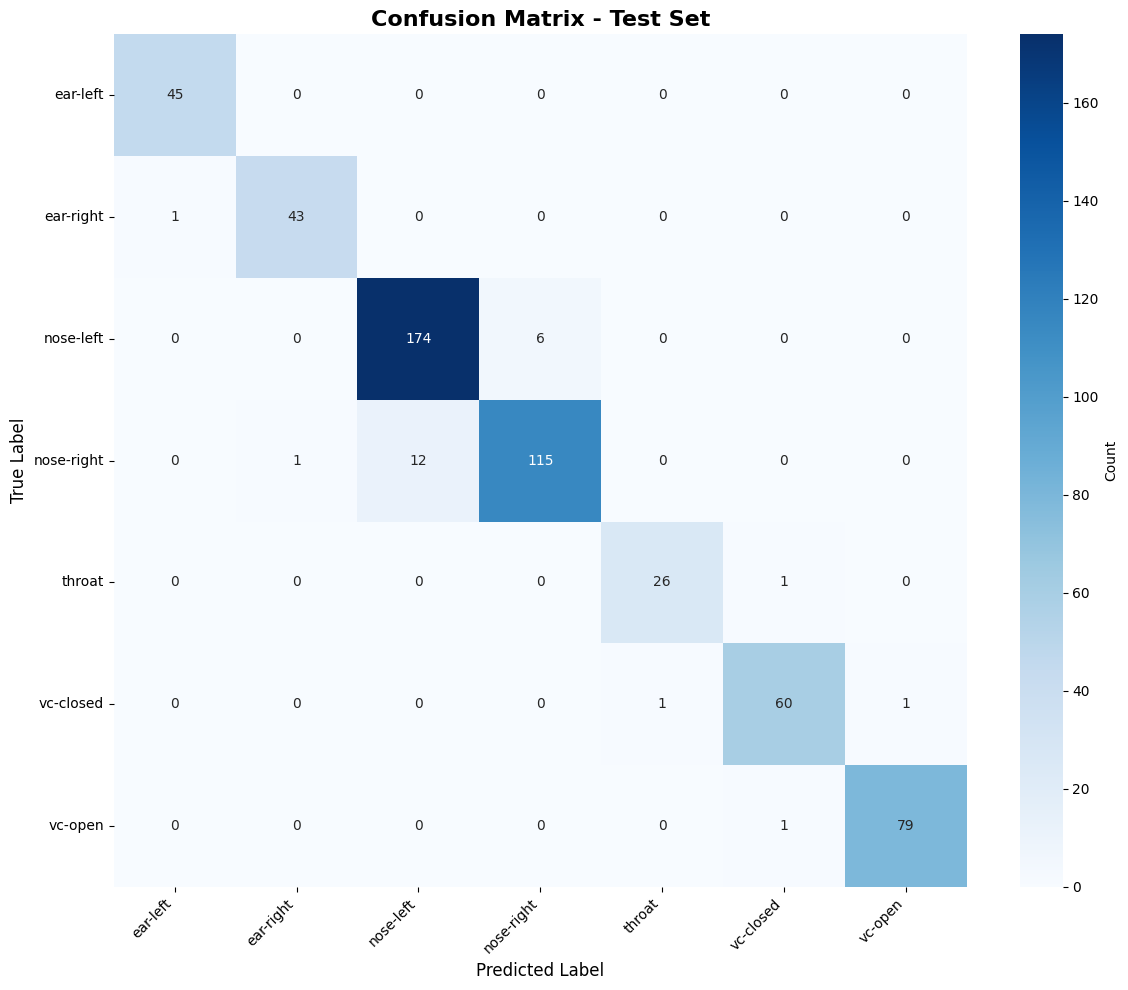

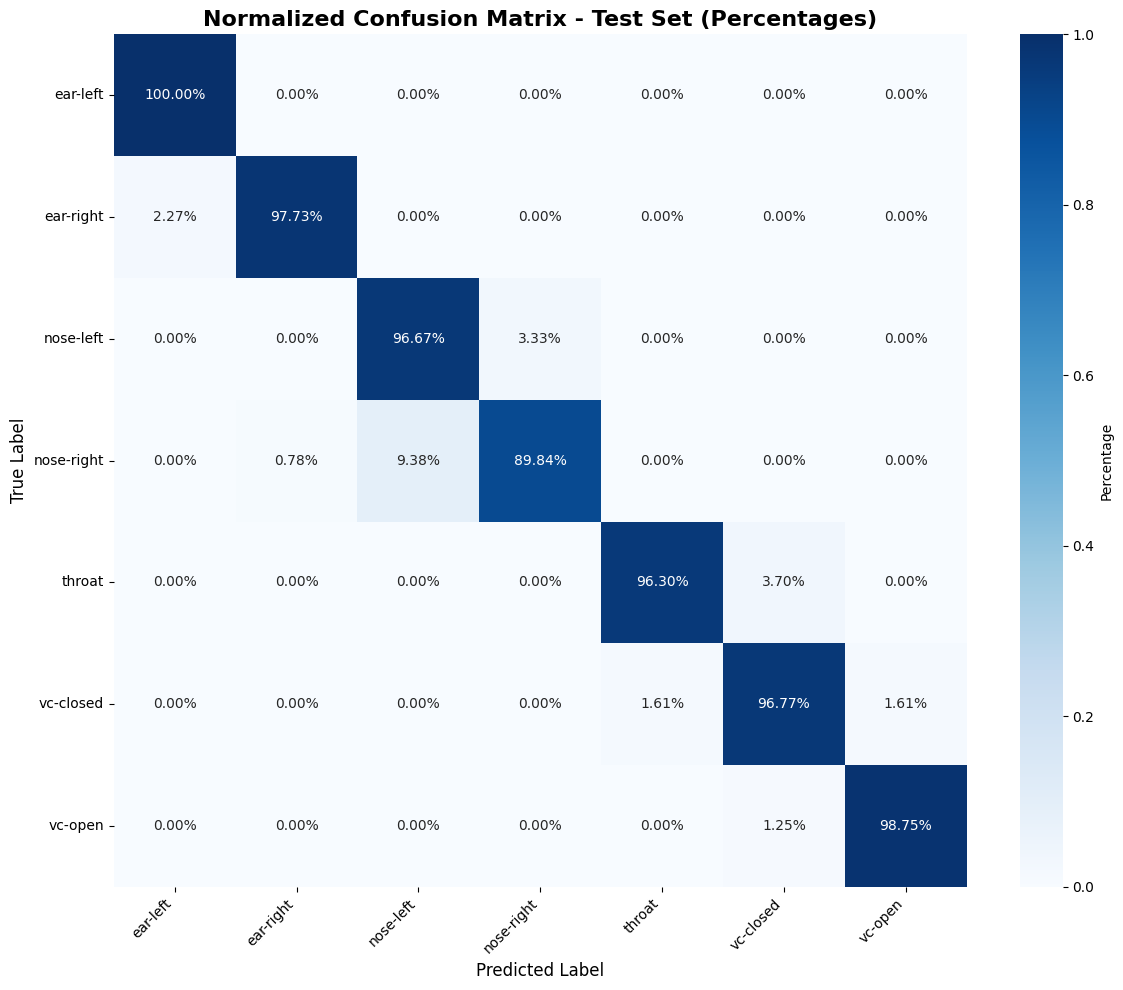

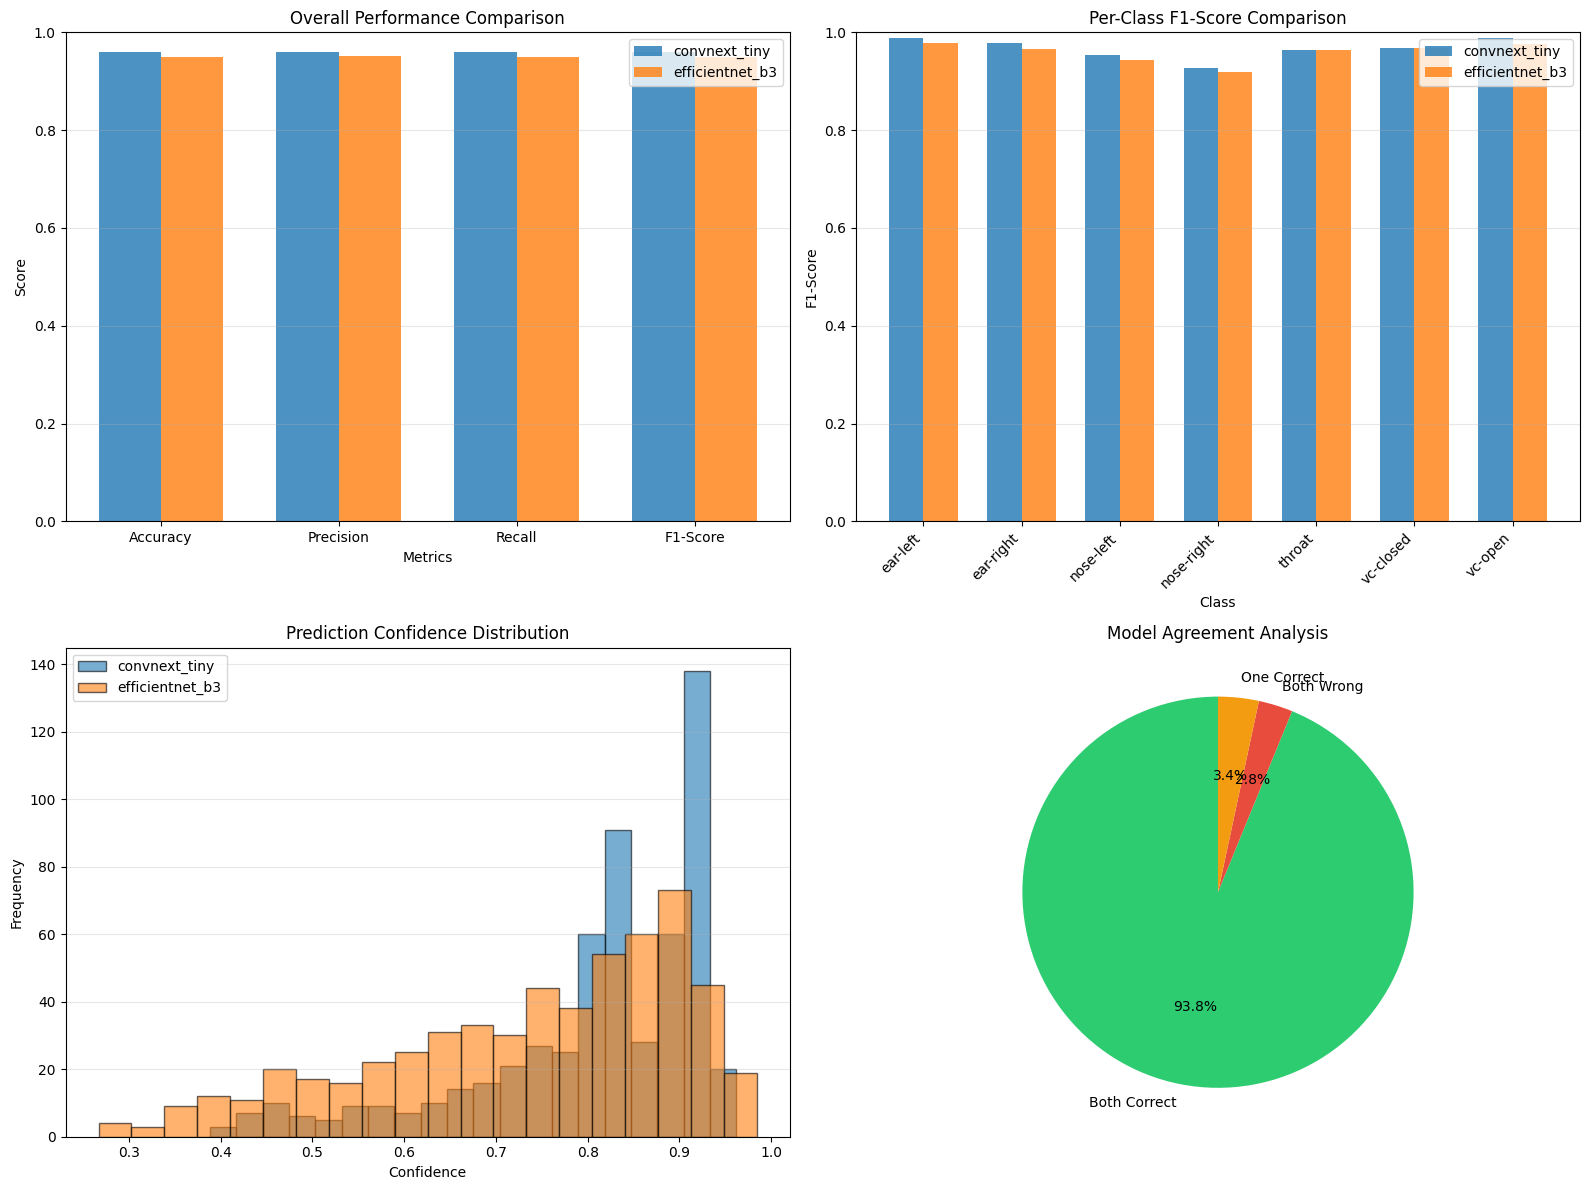

In [ ]:
if __name__ == '__main__':
    inference()